In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [2]:
# Define base directory for datasets
BASE = os.getcwd()
DATASETS_DIR = os.path.join(BASE, "datasets")

In [3]:
# --- Part (a): NSSO68 Dataset Analysis ---

# Load the NSSO68 dataset, handling potential mixed types
df_001 = pd.read_csv(os.path.join(DATASETS_DIR, "NSSO68.csv"), low_memory=False)

In [4]:
# Display unique states to verify data loading
print(df_001['state_1'].unique())

['GUJ' 'ORI' 'CHTSD' 'MP' 'JRKD' 'WB' 'AP' 'MH' 'D&D' 'D&NH' 'MIZ' 'TRPR'
 'MANPR' 'ASSM' 'MEG' 'NAG' 'A&N' 'PNDCRY' 'TN' 'GOA' 'KA' 'KE' 'LKSDP'
 'SKM' 'Bhr' 'UP' 'RJ' 'ARP' 'DL' 'HR' 'Pun' 'HP' 'UT' 'Chandr' 'J$K']


In [5]:
# Filter data for "MEG" state and select relevant columns for analysis
df_001 = df_001[df_001['state_1'] == "MEG"]
df_001 = df_001[['foodtotal_q', 'MPCE_MRP', 'Age', 'Meals_At_Home', 'Possess_ration_card', 'Education', 'No_of_Meals_per_day']]

In [6]:
# Display DataFrame information, including non-null counts and data types
df_001.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259 entries, 17685 to 49444
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   foodtotal_q          1259 non-null   float64
 1   MPCE_MRP             1259 non-null   float64
 2   Age                  1259 non-null   int64  
 3   Meals_At_Home        1251 non-null   float64
 4   Possess_ration_card  1259 non-null   float64
 5   Education            1259 non-null   float64
 6   No_of_Meals_per_day  1258 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.7 KB


In [7]:
# Define a function to impute missing values with the mean for specified columns
def impute_with_mean(df):
    cols_to_impute = ['Meals_At_Home', 'No_of_Meals_per_day']
    for col in cols_to_impute:
        # Fill NaN values with the mean of the respective column
        df[col] = df[col].fillna(df[col].mean())
    return df

# Apply the imputation function to the DataFrame
df_001 = impute_with_mean(df_001)

In [8]:
# Replace infinite values (positive or negative) with NaN
df_001 = df_001.replace([np.inf, -np.inf], np.nan)

# Check for any remaining missing values after imputation and replacement
# This step also confirms the previous dropna was redundant if imputation handled all NaNs
print(df_001.isna().sum())

foodtotal_q            0
MPCE_MRP               0
Age                    0
Meals_At_Home          0
Possess_ration_card    0
Education              0
No_of_Meals_per_day    0
dtype: int64


In [9]:
# Prepare data for OLS regression: 'foodtotal_q' as dependent variable (y)
# and other selected columns as independent variables (X), adding a constant.
y = df_001['foodtotal_q']
X = sm.add_constant(df_001.drop(['foodtotal_q'], axis=1).copy())

In [10]:
# Create and fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(y, X)
outputs = model.fit()

In [11]:
# Print the summary of the regression results
print(outputs.summary())

                            OLS Regression Results                            
Dep. Variable:            foodtotal_q   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     49.41
Date:                Wed, 25 Jun 2025   Prob (F-statistic):           1.22e-54
Time:                        23:42:14   Log-Likelihood:                -3594.6
No. Observations:                1259   AIC:                             7203.
Df Residuals:                    1252   BIC:                             7239.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   9.0136    

In [12]:
# Calculate Variance Inflation Factor (VIF) to check for multicollinearity
vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

               feature         VIF
0                const  401.863559
1             MPCE_MRP    1.199202
2                  Age    1.052001
3        Meals_At_Home    1.065220
4  Possess_ration_card    1.137026
5            Education    1.256799
6  No_of_Meals_per_day    1.039085


In [13]:
# Extract and print the coefficients of the fitted model
coeff = outputs.params
print(coeff)

const                  9.013552
MPCE_MRP               0.001245
Age                    0.052218
Meals_At_Home          0.180090
Possess_ration_card    0.115067
Education              0.207097
No_of_Meals_per_day   -3.427736
dtype: float64


In [14]:
# Construct and print the regression equation
eq = f"y = {round(coeff.iloc[0], 2)}"
for i in range(1, len(coeff)):
    eq += f" + {round(coeff.iloc[i], 6)}*x{i}"
print(eq)

y = 9.01 + 0.001245*x1 + 0.052218*x2 + 0.18009*x3 + 0.115067*x4 + 0.207097*x5 + -3.427736*x6


In [15]:
# Print the first row values of the selected features and the target variable
# This is for inspection and can be removed if not needed for further analysis.
print(df_001['MPCE_MRP'].head(1).values[0])
print(df_001['Age'].head(1).values[0])
print(df_001['Meals_At_Home'].head(1).values[0])
print(df_001['Possess_ration_card'].head(1).values[0])
print(df_001['Education'].head(1).values[0])
print(df_001['No_of_Meals_per_day'].head(1).values[0])
print(df_001['foodtotal_q'].head(1).values[0])

3186.12
47
60.0
1.0
10.0
2.0
29.850725


In [16]:
# Delete the DataFrame to free up memory
del df_001

In [17]:
# --- Part (b): IPL Player Performance and Salary Analysis ---

# Load IPL performance and salary datasets
perf_df = pd.read_csv(os.path.join(DATASETS_DIR, 'IPL_ball_by_ball_updated till 2024.csv'), low_memory=False)
sal_df = pd.read_excel(os.path.join(DATASETS_DIR, 'IPL SALARIES 2024.xlsx'))

In [18]:
# Display columns of the performance DataFrame
print(perf_df.columns)

Index(['Match id', 'Date', 'Season', 'Batting team', 'Bowling team',
       'Innings No', 'Ball No', 'Bowler', 'Striker', 'Non Striker',
       'runs_scored', 'extras', 'type of extras', 'score', 'score/wicket',
       'wicket_confirmation', 'wicket_type', 'fielders_involved',
       'Player Out'],
      dtype='object')


In [19]:
# Get unique player names from the salary DataFrame
players = sal_df['Player'].unique()

In [20]:
# Define Longest Common Subsequence (LCS) score function for string matching
def lcs_score(s1, s2):
    n, m = len(s1), len(s2)
    if n == 0 or m == 0:
        return 0.0

    # Initialize DP table for LCS length calculation
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if s1[i - 1] == s2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    lcs_length = dp[n][m]

    # Calculate LCS score normalized by average length
    average_length = (n + m) / 2.0
    score = lcs_length / average_length
    return score

In [21]:
# Calculate total runs scored by each striker
runs_dict = perf_df.groupby('Striker')['runs_scored'].sum().to_dict()
strikers = perf_df['Striker'].unique()

In [22]:
# Match strikers with full player names using LCS score and collect their runs scored
matches_by_striker = []
for striker in strikers:
    for player in players:
        score = lcs_score(striker, player)
        if score > 0.80: # Threshold for considering a match
            # Find the actual player name from runs_dict that best matches the salary player name
            actual_player_name = max(runs_dict.keys(), key=lambda k: lcs_score(player, k))
            runs_scored = runs_dict.get(actual_player_name, 0)
            matches_by_striker.append({'Player Name': striker, 'Full Name': player, 'Runs_Scored': runs_scored, 'LCS Score': score})

In [23]:
# Create a DataFrame for batsman performance points
ms_df = pd.DataFrame(matches_by_striker)
ms_df['Points for Batsman'] = ms_df['Runs_Scored']
ms_df.to_csv(os.path.join(DATASETS_DIR, 'ms_out.csv'), index=False)

In [24]:
# Calculate total wickets taken by each bowler
wickets_dict = perf_df.groupby('Bowler')['wicket_confirmation'].sum().to_dict()
bowlers = perf_df['Bowler'].unique()

In [25]:
# Match bowlers with full player names using LCS score and collect their wickets taken
matches_by_bowler = []
for bowler in bowlers:
    for player in players:
        score = lcs_score(bowler, player)
        if score > 0.80: # Threshold for considering a match
            # Find the actual player name from wickets_dict that best matches the salary player name
            actual_player_name = max(wickets_dict.keys(), key=lambda k: lcs_score(player, k))
            wickets_taken = wickets_dict.get(actual_player_name, 0)
            matches_by_bowler.append({'Player Name': bowler, 'Full Name': player, 'Wickets_Taken': wickets_taken, 'LCS Score': score})

In [26]:
# Create a DataFrame for bowler performance points
mb_df = pd.DataFrame(matches_by_bowler)
mb_df['Points for Bowler'] = mb_df['Wickets_Taken'] * 25 # Assuming 25 points per wicket
mb_df.to_csv(os.path.join(DATASETS_DIR, 'mb_out.csv'), index=False)

In [27]:
# Merge batsman and bowler performance dataframes on 'Full Name'
combine_df = pd.merge(ms_df, mb_df, on='Full Name', how='outer', suffixes=('_Batsman', '_Bowler'))
print(combine_df.head())

  Player Name_Batsman        Full Name  Runs_Scored  LCS Score_Batsman  \
0         Abdul Samad      Abdul Samad        545.0           1.000000   
1       Abishek Porel   Abhishek Porel        235.0           0.962963   
2     Abhishek Sharma  Abhishek Sharma       1196.0           1.000000   
3             A Zampa       Adam Zampa         15.0           0.823529   
4          Akash Deep       Akash Deep         19.0           1.000000   

   Points for Batsman Player Name_Bowler  Wickets_Taken  LCS Score_Bowler  \
0               545.0        Abdul Samad            2.0          1.000000   
1               235.0                NaN            NaN               NaN   
2              1196.0    Abhishek Sharma            9.0          1.000000   
3                15.0            A Zampa           30.0          0.823529   
4                19.0         Akash Deep            8.0          1.000000   

   Points for Bowler  
0               50.0  
1                NaN  
2              225.0  


In [28]:
# Fill NaN values in 'Points for Batsman' and 'Points for Bowler' with 0
combine_df['Points for Batsman'] = combine_df['Points for Batsman'].fillna(0)
combine_df['Points for Bowler'] = combine_df['Points for Bowler'].fillna(0)

In [29]:
# Calculate total points by summing batsman and bowler points.
combine_df['Total Points'] = combine_df['Points for Batsman'] + combine_df['Points for Bowler']
combine_df.to_csv(os.path.join(DATASETS_DIR, 'combined_out.csv'), index=False)

In [30]:
# Add salary information to the combined DataFrame
combine_df['Salary'] = np.nan
for idx, row in combine_df.iterrows():
    if row['Full Name'] in sal_df['Player'].to_list():
        combine_df.at[idx, 'Salary'] = sal_df[sal_df['Player'] == row['Full Name']]['Rs'].values[0]

In [31]:
# Display the combined DataFrame with performance points and salary
print(combine_df)

   Player Name_Batsman          Full Name  Runs_Scored  LCS Score_Batsman  \
0          Abdul Samad        Abdul Samad        545.0           1.000000   
1        Abishek Porel     Abhishek Porel        235.0           0.962963   
2      Abhishek Sharma    Abhishek Sharma       1196.0           1.000000   
3              A Zampa         Adam Zampa         15.0           0.823529   
4           Akash Deep         Akash Deep         19.0           1.000000   
..                 ...                ...          ...                ...   
63         Umran Malik        Umran Malik         23.0           1.000000   
64           V Shankar      Vijay Shankar       1105.0           0.818182   
65        Vishnu Vinod       Vishnu Vinod         56.0           1.000000   
66   Washington Sundar  Washington Sundar        378.0           1.000000   
67                 NaN        Yash Thakur          NaN                NaN   

    Points for Batsman Player Name_Bowler  Wickets_Taken  LCS Score_Bowler 

In [32]:
# Save the combined DataFrame with salary to a CSV file
combine_df.to_csv(os.path.join(DATASETS_DIR, 'combined_out_with_sal.csv'), index=False)

In [33]:
# Prepare data for linear regression: 'Total Points' as independent variable (X) and 'Salary' as dependent variable (y)
optim_agg_combine_df = combine_df[['Full Name', 'Total Points', 'Salary']]
optim_agg_combine_df.to_csv(os.path.join(DATASETS_DIR, 'optim_combine_df_with_sal.csv'), index=False)

y = optim_agg_combine_df['Salary']
X = optim_agg_combine_df[['Total Points']]

In [34]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [35]:
# Initialize and fit the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [36]:
# Make predictions and evaluate the model (R-squared and Mean Squared Error)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r2}")
print(f"Mean Squared Error: {mse}")

R-squared: -0.0010303912220006595
Mean Squared Error: 231343.31907087436


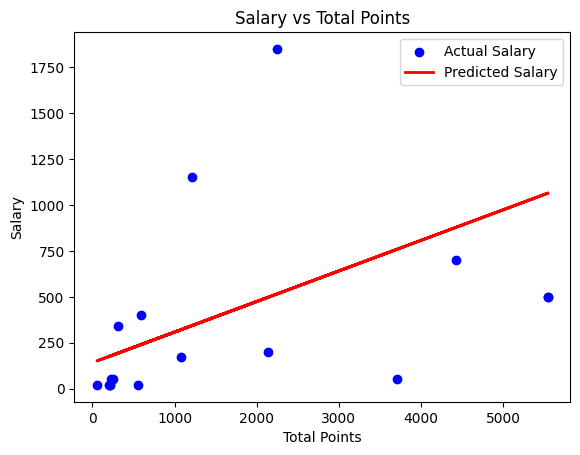

In [37]:
# Plotting the regression results
plt.scatter(X_test, y_test, color='blue', label='Actual Salary')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Salary')
plt.xlabel('Total Points')
plt.ylabel('Salary')
plt.title('Salary vs Total Points')
plt.legend()
plt.show()